In [3]:
import pandas as pd
df = pd.read_csv('/content/Salary_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [4]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [11]:
for col in ['Age', 'Years of Experience', 'Salary']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

for col in ['Gender', 'Education Level', 'Job Title']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify that there are no more null values
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to categorical columns
for col in ['Gender', 'Education Level', 'Job Title']:
    df[col] = le.fit_transform(df[col])

# Display the first few rows of the updated DataFrame
display(df.head())

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,177,5.0,90000.0
1,28.0,0,3,18,3.0,65000.0
2,45.0,1,5,145,15.0,150000.0
3,36.0,0,0,116,7.0,60000.0
4,52.0,1,3,26,20.0,200000.0


In [13]:
# Separate independent and dependent variables
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Independent variables (X):")
display(X.head())

print("\nDependent variable (y):")
display(y.head())

Independent variables (X):


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,177,5.0
1,28.0,0,3,18,3.0
2,45.0,1,5,145,15.0
3,36.0,0,0,116,7.0
4,52.0,1,3,26,20.0



Dependent variable (y):


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5363, 5)
X_test shape: (1341, 5)
y_train shape: (5363,)
y_test shape: (1341,)


### Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

Linear Regression - Mean Squared Error: 892668414.69
Linear Regression - R-squared: 0.67


### Decision Tree Regressor Model

In [16]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor - Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error: 93817976.26
Decision Tree Regressor - R-squared: 0.96


### Random Forest Regressor Model

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error: 65085758.85
Random Forest Regressor - R-squared: 0.98


### Support Vector Machine (SVR) Model

In [18]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVMs are sensitive to feature scaling, so we'll scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVR model
# Using a linear kernel for simplicity, can be changed to rbf etc.
svr_model = SVR(kernel='linear')
svr_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Support Vector Regressor - Mean Squared Error: {mse_svr:.2f}")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error: 2099497053.86
Support Vector Regressor - R-squared: 0.21


### K-Nearest Neighbors (KNN) Regressor Model

In [19]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize and train the K-Nearest Neighbors Regressor model
# Using default n_neighbors=5, can be tuned
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Regressor - Mean Squared Error: {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error: 101306941.19
K-Nearest Neighbors Regressor - R-squared: 0.96


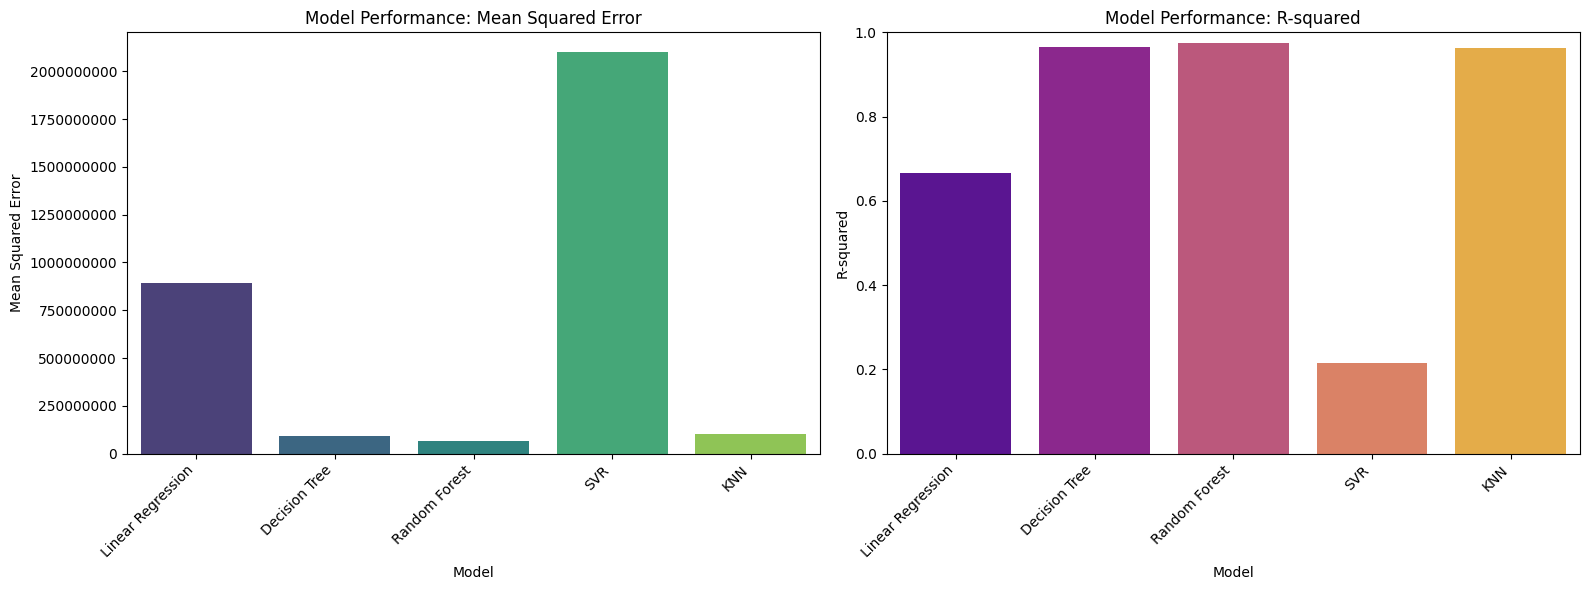

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN'],
    'MSE': [mse_lr, mse_dt, mse_rf, mse_svr, mse_knn],
    'R-squared': [r2_lr, r2_dt, r2_rf, r2_svr, r2_knn]
}

df_metrics = pd.DataFrame(metrics_data)

# Create subplots for MSE and R-squared
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot MSE
sns.barplot(x='Model', y='MSE', data=df_metrics, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Model Performance: Mean Squared Error')
axes[0].set_ylabel('Mean Squared Error')
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot R-squared
sns.barplot(x='Model', y='R-squared', data=df_metrics, ax=axes[1], palette='plasma', hue='Model', legend=False)
axes[1].set_title('Model Performance: R-squared')
axes[1].set_ylabel('R-squared')
axes[1].set_ylim(0, 1) # R-squared typically ranges from 0 to 1
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
import pickle

# Assuming random_forest_model is the best model based on previous evaluation
# Save the best model to a file
with open('best_model.pkl', 'wb') as file:
    pickle.dump(random_forest_model, file)

print("Best model (Random Forest Regressor) saved as best_model.pkl")

Best model (Random Forest Regressor) saved as best_model.pkl
